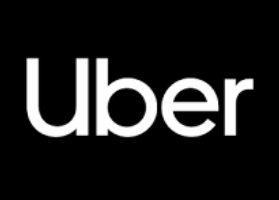

#**UBER PROJECT QUESTIONS**

## DATA LOADING

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
df = pd.read_csv("/content/ncr_ride_bookings.csv", encoding='latin-1')

In [33]:
df

,Day,Month,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,...,Avg _CTAT,Cancelled_Rides_by_Customer,Reason_for_cancelling_by_Customer,Cancelled_Rides_by_Driver,Driver_Cancellation_Reason,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating,Payment_Method
0,Saturday,March,23-03-2024,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,...,29.1,not mentioned,Not specified,not mentioned,not specified,509,24.60,4.3,4.5,Cash
1,Friday,November,29-11-2024,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,...,14.0,not mentioned,Not specified,not mentioned,not specified,237,5.73,4.3,4.5,UPI
2,Friday,August,23-08-2024,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,...,25.8,not mentioned,Not specified,not mentioned,not specified,627,13.58,4.9,4.9,Debit Card
3,Monday,October,21-10-2024,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,...,28.5,not mentioned,Not specified,not mentioned,not specified,416,34.02,4.6,5.0,UPI
4,Monday,September,16-09-2024,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,...,19.6,not mentioned,Not specified,not mentioned,not specified,737,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,Monday,November,11-11-2024,19:34:01,NaN,Completed,NaN,Go Mini,MG Road,Ghitorni,...,44.4,not mentioned,Not specified,not mentioned,not specified,475,40.08,3.7,4.1,Uber Wallet
149996,Sunday,November,24-11-2024,15:55:09,NaN,Completed,NaN,Go Mini,Golf Course Road,Akshardham,...,30.8,not mentioned,Not specified,not mentioned,not specified,1093,21.31,4.8,5.0,UPI
149997,Wednesday,September,18-09-2024,10:55:15,NaN,Completed,NaN,Go Sedan,Satguru Ram Singh Marg,Jor Bagh,...,23.4,not mentioned,Not specified,not mentioned,not specified,852,15.93,3.9,4.4,Cash
149998,Saturday,October,05-10-2024,07:53:34,NaN,Completed,NaN,Auto,Ghaziabad,Saidulajab,...,39.6,not mentioned,Not specified,not mentioned,not specified,333,45.54,4.1,3.7,UPI


In [ ]:
df.columns

Index(['4', '18:53:40', '"CNR1930744"', 'Completed', '"CID3672643"', 'Go Mini',
       'ITO', 'South Extension', '9.8', '36.5', 'not mentioned',
       'Not specified', 'not mentioned.1', 'not specified', '1225', '45.79',
       '4.3', '4.8', 'Uber Wallet'],
      dtype='object')

In [36]:
df.dtypes

,0
Day,object
Month,object
Date,datetime64[ns]
Time,datetime64[ns]
Booking_ID,object
Booking_Status,object
Customer_ID,object
Vehicle_Type,object
Pickup_Location,object
Drop_Location,object


## Data cleaning (changing date,time data type)

In [34]:
df['Date']= pd.to_datetime(df['Date'])

/tmp/ipython-input-2691600196.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date']= pd.to_datetime(df['Date'])


In [35]:
df['Time'] = pd.to_datetime(df['Time'])

/tmp/ipython-input-2145562215.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time'])


## Questions

Q1. What is the total revenue generated from all rides?

In [37]:
total_revenue = df['Booking_Value'].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 76278183


Q2. Which vehicle type generated the highest revenue?

In [38]:
highest_revenue_vehicle = df.groupby('Vehicle_Type')['Booking_Value'].sum().idxmax()
print("Vehicle Type with Highest Revenue:", highest_revenue_vehicle)

Vehicle Type with Highest Revenue: Auto


In [39]:
highest_revenue_vehicle = df.groupby('Vehicle_Type')['Booking_Value'].sum()
print("Vehicle Type with Highest Revenue:", highest_revenue_vehicle)

Vehicle Type with Highest Revenue: Vehicle_Type
Auto             18988458
Bike             11479592
Go Mini          15144474
Go Sedan         13860626
Premier Sedan     9225496
Uber XL           2242668
eBike             5336869
Name: Booking_Value, dtype: int64


Q3. What is the average ride distance for completed rides?

In [40]:
average_ride_distance = df[df['Booking_Status'] == 'Completed']['Ride_Distance'].mean()
print("Average Ride Distance for Completed Rides:", average_ride_distance)

Average Ride Distance for Completed Rides: 26.000492903225805


Q4. Which day of the week has the most bookings?

In [41]:
most_booking_day = df['Day'].value_counts().idxmax()
print("day_with_maximum_bookings =", most_booking_day)

day_with_maximum_bookings = Monday


In [42]:
most_booking_day = df['Day'].value_counts()
print("day_with_maximum_bookings ", most_booking_day)

day_with_maximum_bookings  Day
Monday       21644
Saturday     21542
Wednesday    21413
Sunday       21398
Friday       21397
Tuesday      21391
Thursday     21215
Name: count, dtype: int64


Q5. Top 5 pickup locations by number of bookings

In [43]:
top_5_pickup_locations = df['Pickup_Location'].value_counts().head(5)
print("Top 5 Pickup Locations by Number of Bookings:")
print(top_5_pickup_locations)

Top 5 Pickup Locations by Number of Bookings:
Pickup_Location
Khandsa            949
Barakhamba Road    946
Saket              931
Badarpur           921
Pragati Maidan     920
Name: count, dtype: int64


Q6. Distribution of payment methods used by customers

In [44]:
payment_method_distribution = df['Payment_Method'].value_counts()
print("Distribution of Payment Methods Used by Customers:")
print(payment_method_distribution)


Distribution of Payment Methods Used by Customers:
Payment_Method
Cash           73367
UPI            45909
Uber Wallet    12276
Credit Card    10209
Debit Card      8239
Name: count, dtype: int64


Q7. Find the average driver rating per vehicle type

In [45]:
Avg_Driver_Ratings = df.groupby('Vehicle_Type')['Driver_Ratings'].mean()
print("Average Driver Ratings per Vehicle Type:")
print(Avg_Driver_Ratings)

Average Driver Ratings per Vehicle Type:
Vehicle_Type
Auto             4.258150
Bike             4.256406
Go Mini          4.255002
Go Sedan         4.258104
Premier Sedan    4.259533
Uber XL          4.261430
eBike            4.253841
Name: Driver_Ratings, dtype: float64


Q8. Which month had the highest revenue?

In [46]:
Month_with_highest_revenue = df.groupby(df['Month'])['Booking_Value'].sum()

print("Month with Highest Revenue:", Month_with_highest_revenue)

Month with Highest Revenue: Month
April        6209367
August       6341098
December     6308790
February     6059692
January      6498987
July         6487435
June         6333665
March        6623530
May          6410124
November     6351400
October      6445535
September    6208560
Name: Booking_Value, dtype: int64


## **Graph Questions**

 Q9. Show total revenue by vehicle type

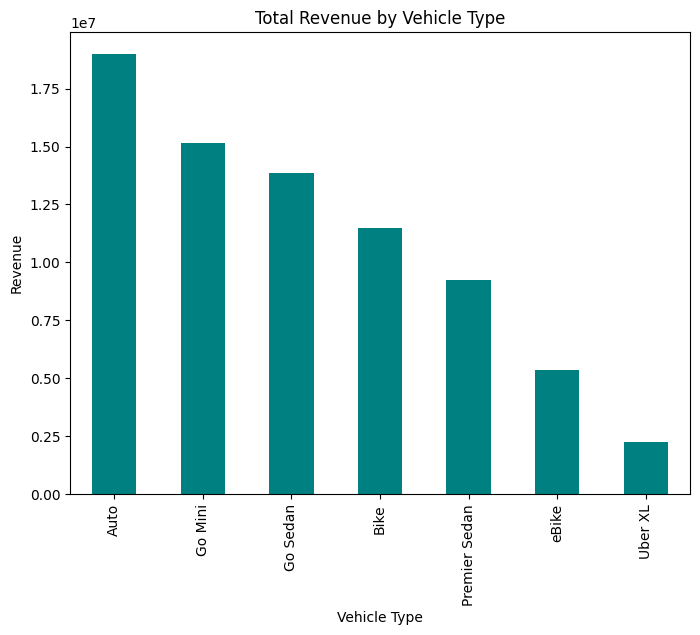

In [47]:
Total_revenue_by_vehicle_type = df.groupby('Vehicle_Type')['Booking_Value'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,6))
Total_revenue_by_vehicle_type.plot(kind='bar', color='Teal')
plt.title("Total Revenue by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Revenue")
plt.show()

Q10. Plot number of bookings by day of the week

Text(0.5, 0, 'Day of the Week')

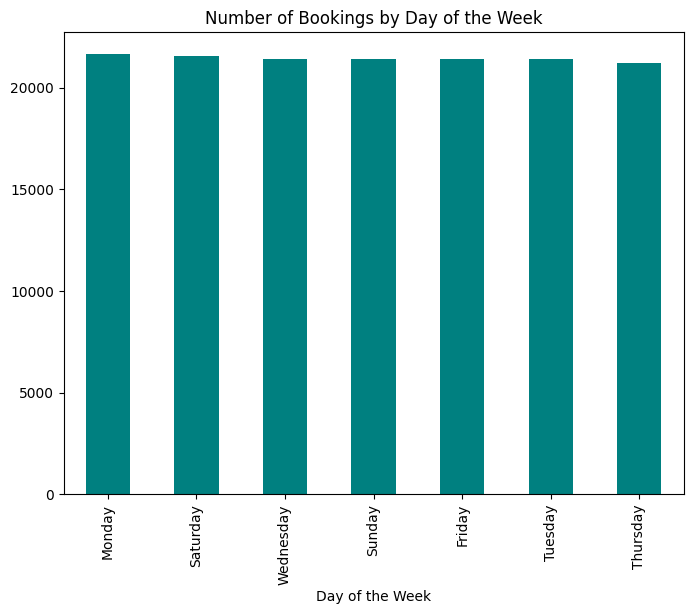

In [48]:
No_of_bookings_by_day = df['Day'].value_counts()
plt.figure(figsize=(8,6))
No_of_bookings_by_day.plot(kind='bar', color='Teal')
plt.title("Number of Bookings by Day of the Week")
plt.xlabel("Day of the Week")

Q11. Monthly trend of revenue

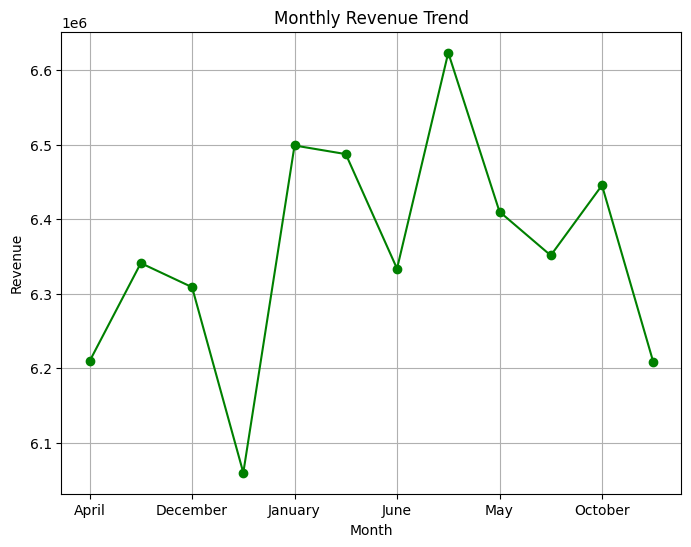

In [49]:
Month_wise_revenu = df.groupby(df['Month'])['Booking_Value'].sum()
plt.figure(figsize=(8,6))
Month_wise_revenu.plot(kind='line', marker='o', color='green')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()